<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/tabular_data/parkinson_detection/Parkinson_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Загрузка данных
url = 'https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data'
data = pd.read_csv(url)

print(f"Размер датасета: {data.shape}")
print(f"Количество признаков: {data.shape[1] - 1}")  # -1 для исключения столбца name

data.head()

Размер датасета: (195, 24)
Количество признаков: 23


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
# Анализ датасета
print("Проверка на пропущенные значения:")
print(data.isnull().sum().sum())
print("\nРаспределение классов:")
print(data['status'].value_counts())
print(f"Процент больных: {data['status'].mean() * 100:.2f}%")

Проверка на пропущенные значения:
0

Распределение классов:
status
1    147
0     48
Name: count, dtype: int64
Процент больных: 75.38%


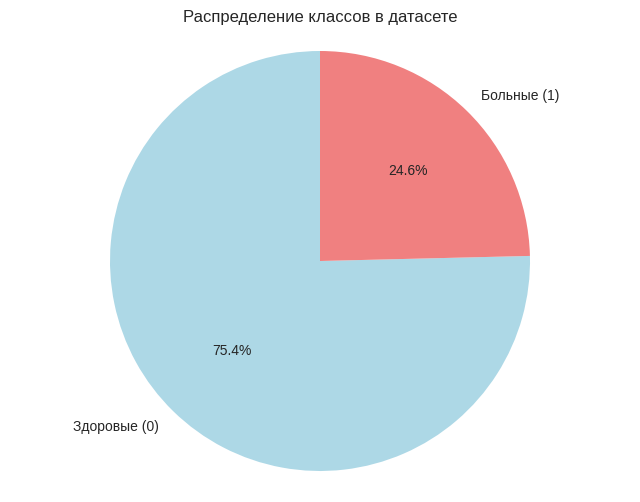

Здоровые пациенты: 48 (24.6%)
Больные пациенты: 147 (75.4%)


In [ ]:
# Визуализация распределения классов
plt.figure(figsize = (8, 6))
status_counts = data['status'].value_counts()
colors = ['lightblue', 'lightcoral']
plt.pie(status_counts.values, labels = ['Здоровые (0)', 'Больные (1)'], autopct = '%1.1f%%',
        colors = colors, startangle = 90)
plt.title('Распределение классов в датасете')
plt.axis('equal')
plt.show()

print(f"Здоровые пациенты: {status_counts[0]} ({status_counts[0] / len(data) * 100:.1f}%)")
print(f"Больные пациенты: {status_counts[1]} ({status_counts[1] / len(data) * 100:.1f}%)")


In [ ]:
# Предобработка данных
# Удаляем столбец 'name', так как он не является признаком
X = data.drop(['name', 'status'], axis = 1)
y = data['status']

print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")
print(f"Названия признаков: {list(X.columns)}")


Признаки (X): (195, 22)
Целевая переменная (y): (195,)
Названия признаков: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [ ]:
# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")

# Проверяем распределение классов в выборках, особо обращая внимание на обучающую
print(f"\nРаспределение классов в обучающей выборке:")
print(f"Здоровые: {(y_train == 0).sum()} ({(y_train == 0).mean() * 100:.1f}%)")
print(f"Больные: {(y_train == 1).sum()} ({(y_train == 1).mean() * 100:.1f}%)")

print(f"\nРаспределение классов в тестовой выборке:")
print(f"Здоровые: {(y_test == 0).sum()} ({(y_test == 0).mean() * 100:.1f}%)")
print(f"Больные: {(y_test == 1).sum()} ({(y_test == 1).mean() * 100:.1f}%)")


Обучающая выборка: 156 образцов
Тестовая выборка: 39 образцов

Распределение классов в обучающей выборке:
Здоровые: 38 (24.4%)
Больные: 118 (75.6%)

Распределение классов в тестовой выборке:
Здоровые: 10 (25.6%)
Больные: 29 (74.4%)


In [ ]:
scaler = StandardScaler()

# Применяем нормализацию к обеим выборкам
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Проверяем результат нормализации
print(f"\nСтатистики обучающей выборки после нормализации:")
print(f"Среднее: {X_train_scaled.mean(axis = 0).mean():.6f}")
print(f"Стандартное отклонение: {X_train_scaled.std(axis = 0).mean():.6f}")

print(f"\nСтатистики тестовой выборки после нормализации:")
print(f"Среднее: {X_test_scaled.mean(axis = 0).mean():.6f}")
print(f"Стандартное отклонение: {X_test_scaled.std(axis = 0).mean():.6f}")



Статистики обучающей выборки после нормализации:
Среднее: -0.000000
Стандартное отклонение: 1.000000

Статистики тестовой выборки после нормализации:
Среднее: 0.000000
Стандартное отклонение: 1.000000


In [ ]:
xgb_model = XGBClassifier(
    n_estimators = 100,          # Количество деревьев
    max_depth = 6,               # Максимальная глубина дерева
    learning_rate = 1.99,        # Скорость обучения
    subsample = 0.8,             # Доля образцов для каждого дерева
    colsample_bytree = 0.8,      # Доля признаков для каждого дерева
    random_state = 42,           # Для воспроизводимости результатов
    eval_metric = 'logloss',     # Метрика для бинарной классификации
    early_stopping_rounds = 10   # Остановка при отсутствии улучшения
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set = [(X_test_scaled, y_test)],
    verbose = False
)
print("Модель обучена")

Модель обучена


In [ ]:
# Оценка точности модели
y_pred = xgb_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

print("\nОтчет по различным показателям: \n")
print(classification_report(y_test, y_pred, target_names=['Здоровые', 'Больные']))

# Составим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)


Точность модели на тестовой выборке: 0.9744

Отчет по различным показателям: 

              precision    recall  f1-score   support

    Здоровые       0.91      1.00      0.95        10
     Больные       1.00      0.97      0.98        29

    accuracy                           0.97        39
   macro avg       0.95      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39



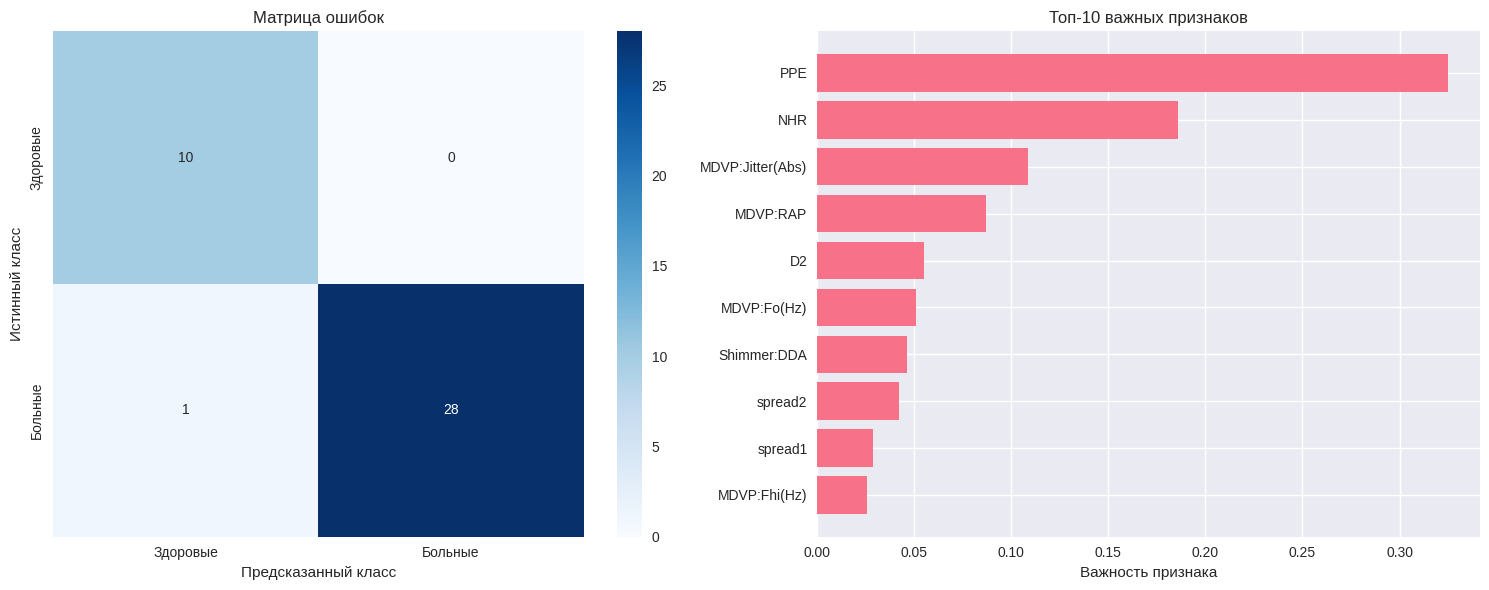

In [ ]:
# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize = (15, 6))

# Матрица ошибок
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Здоровые', 'Больные'],
            yticklabels = ['Здоровые', 'Больные'],
            ax = axes[0])
axes[0].set_title('Матрица ошибок')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending = False)

# Топ-10 важных признаков
top_features = feature_importance.head(10)
axes[1].barh(range(len(top_features)), top_features['importance'])
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['feature'])
axes[1].set_xlabel('Важность признака')
axes[1].set_title('Топ-10 важных признаков')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Данный проект реализует предсказание заболевания Паркинсона на ранней стадии с использованием алгоритма машинного обучения XGBoost и нормализацией признаков посредством StandardScaler. Получилось достичь высокой точности (97%).

Модель выявила наиболее значимые параметры для диагностики болезни, что может быть полезно для медицинских специалистов.

### Практическое применение:

1. Модель может использоваться как вспомогательный инструмент для ранней диагностики
2. Высокая точность модели позволяет использовать ее в медицинских системах поддержки принятия решений (разумеется, только в качестве советчика).
